In [1]:
# Imports
import sys
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

In [2]:
# CD-NLGSSM imports
from cd_dynamax import make_key_sequence
from cd_dynamax.src.utils.experiment_utils import *
from cd_dynamax.src.utils.simulation_utils import filter_and_forecast
from cd_dynamax.src.utils.demo_utils import sample_t_emissions

# Python plotting import
sys.path.append("../scripts")
from filter_forecast_plotting_utils import (
    data_plotter,
    plot_filter_then_forecast_state_results,
)
from parameter_learning_plotting_utils import (
    learnable_params_to_1d_df,
    plot_mll_learning_curve,
    plot_param_sequences
)

# Set default config path
config_path = "../configs/"

## Define the Lorenz 63 Model


We generate data from a Lorenz 63 system, from dynamics with the following stochastic differential equations:

\begin{align*}
\frac{d x}{d t} &= a(y-x) + \sigma w_x(t) \\
\frac{d y}{d t} &= x(b-z) - y + \sigma w_y(t) \\
\frac{d z}{d t} &= xy - cz + \sigma w_z(t),
\end{align*}

With parameters $a=10, b=28, c=8/3$, the system gives rise to chaotic behavior, and we choose $\sigma=1.0$ for diffusion.

To generate data, we numerically approximate random path solutions to this SDE using Heun's method (i.e. improved Euler), as implemented in [Diffrax](https://docs.kidger.site/diffrax/api/solvers/sde_solvers/).


We assume the observation model is
\begin{align*}
y(t) &= H x(t) + r(t) \\
r(t) &\sim N(0,R),
\end{align*}
where we choose $R=I$. 

Namely, **we impose partial observability with H=[1, 0, 0]**, with noisy observations, sampled at irregular time intervals.

In [3]:
# Default Lorenz 63 parameter definition in config file
# where only the first component (x_1) is observed
default_lorenz63_config_model = "model/l63_x1_filter"

In [4]:
# Specify true Lorenz '63 parameters
from cd_dynamax.src.utils.physics_based_models import LearnableLorenz63_Drift

# Define the True Lorenz 63 Model parameters dictionary
true_model_def = {
    'initial_values.dynamics_drift': {
        "params": LearnableLorenz63_Drift(
            sigma=10.0,
            rho=28.0,
            beta=8.0 / 3.0
        ),
        "props": None # Let us use the default parameter properties
    }
}


In [5]:
# Create and initialize the CD-NLGSSM model
true_model, true_params, true_props = create_cddynamax_model_from_config(
    config_path=config_path,
    true_model_config_file=default_lorenz63_config_model,
    overrides=true_model_def,
)

### Simulate data using true CDNLGSSM model

In [6]:
# Simulate emission times
keys = make_key_sequence(0)
t_emissions = sample_t_emissions(
    start=0.0,
    stop=50.0,
    dt=0.01,
    regular=False,
    key=next(keys)
)

# Simulate data using true parameters (observed at times t_emissions)
# Note that default SDE diffeqsolve settings solve using dfx.Heun() with dfx.ConstantStepSize() and dt0=0.01 step size.
states, emissions = true_model.sample(
    params=true_params,
    key=next(keys),
    num_timesteps=len(t_emissions),
    t_emissions=t_emissions,
    transition_type="path",
)

[make_t_emissions] Generated 5000 points from 0.0 to 50.0 with avg step ~0.0100
[make_t_emissions] Smallest time step = 0.000004
Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete non-linear Gaussian SSM path


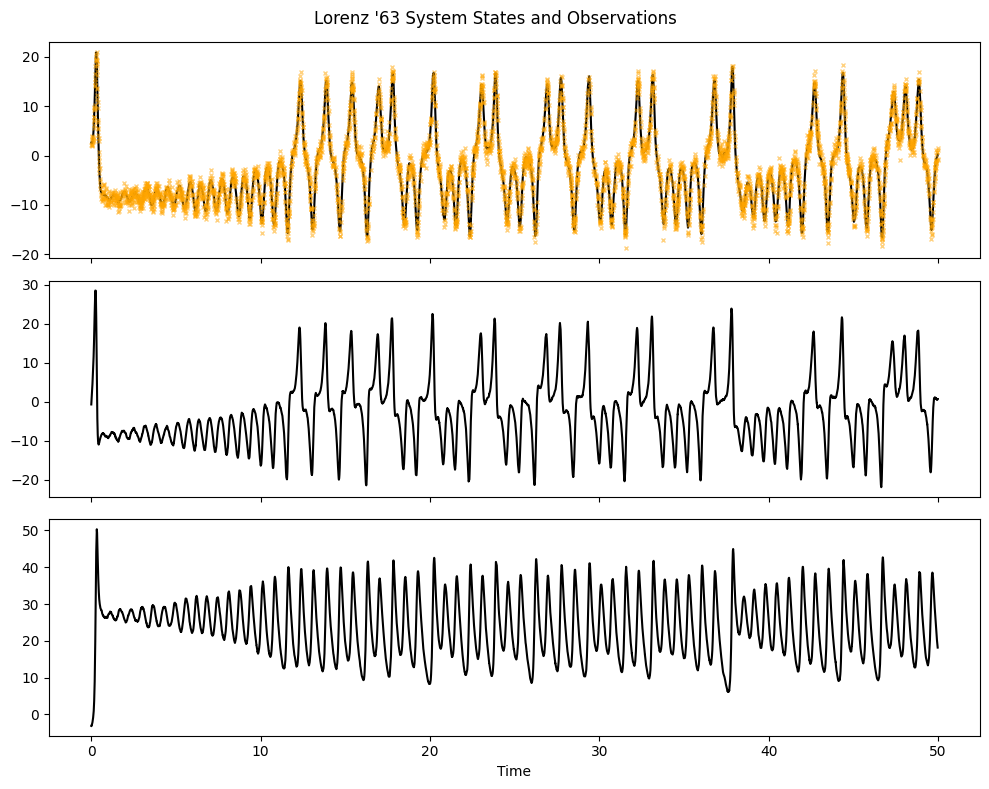

In [7]:
# Plot the results in a subplot with 3 rows, with observations overlaid in first emission_dims rows
fig, axes = plt.subplots(
    true_model.state_dim,
    1,
    figsize=(10, 8),
    sharex=True
)
state_labels = ['x', 'y', 'z']
for d in range(true_model.state_dim):
    ### True data
    data_plotter(
        ax=axes[d],
        t_idx=t_emissions,
        states=states[:, d],
        state_label=state_labels[d],
        state_style={'color': 'black', 'linestyle': '-', 'linewidth': 1.5},
        emissions=emissions[:, d] if d < emissions.shape[1] else None,
        emission_label='True Observation' if d < emissions.shape[1] else None,
        emissions_style={'color': 'orange', 'linestyle': 'None', 'marker': 'x', 'markersize': 3, 'alpha': 0.5},
        plot_observations=True and d < emissions.shape[1],
    )
axes[-1].set_xlabel('Time')
plt.suptitle('Lorenz \'63 System States and Observations')
plt.tight_layout()
plt.show()

## Fitting another Lorenz 63 model to the data

### Learnable model definition 

In [8]:
# New Lorenz 63 model definition in config file
# where only the first component (x_1) is observed
learnable_lorenz63_config_model = "model/l63_x1_fit_to_data"

# If desired, we can override the initial parameters here
# We will simply override the prior used to draw the initial drift parameters
learnable_model_def = {
    'prior.prior_class_file': 'prior/l63_mech_drift_hi_info.py'
}

In [9]:
# Create and initialize the CD-NLGSSM model
learnable_model, learnable_params, learnable_props = create_cddynamax_model_from_config(
    config_path=config_path,
    true_model_config_file=learnable_lorenz63_config_model,
    overrides=learnable_model_def,
)

Attempting to load prior from: /home/iurteaga/BCAM/academic/projects/matt_levine/cd_dynamax_private/demos/python/configs/prior/l63_mech_drift_hi_info.py
Successfully loaded prior from: /home/iurteaga/BCAM/academic/projects/matt_levine/cd_dynamax_private/demos/python/configs/prior/l63_mech_drift_hi_info.py
Prior instantiated from class: CDNLGSSM_Prior
Initializing dynamics_drift with sampled parameters


## Fitting: SGD-based optimization of log-likelihood, computed via Extended Kalman Filter (EKF) 

Extended Kalman Filter (EKF)

In [10]:
# Default EKF settings are defined in config file
default_ekf_config = "filter/ekf_StateFirst_EmissionsFirst"

In [11]:
# Figure-out the filtering/smoothing settings from config
ekf_hyperparams, ekf_info = create_cddynamax_filter_from_config(
    config_path=config_path,
    filter_config_file=default_ekf_config,
    overrides={}
)

SGD for log-likelihood maximization

In [12]:
# Load SGD fitting configuration

# Fit configuration file
fit_config_file = "fitting/sgd_l63_x1_fit_to_data"

# Full path to the fit config file
fit_config_filepath = os.path.join(config_path, fit_config_file)

# Check if the config file exists
if not os.path.exists(fit_config_filepath):
    raise FileNotFoundError(f"Configuration file '{fit_config_filepath}' not found.")

# Read the fitting configuration
from configparser import ConfigParser
config = ConfigParser()
config.read(fit_config_filepath)

# For each optimization method specified in the config
optim_configs = config.sections()

In [13]:
# Run SGD for parameter estimation
import optax
if 'sgd' in optim_configs:
    # SGD configuration
    sgd_config = config['sgd']
    # SGD MAP estimation via the cd-dynamax learnable_model's fit_sgd method
    print("\nStarting SGD fitting...")
    fit_results = learnable_model.fit_sgd(
        initial_params = learnable_params,
        props=learnable_props,
        emissions=emissions,
        t_emissions=t_emissions,
        filter_hyperparams=ekf_hyperparams,
        inputs=None,
        optimizer=eval(sgd_config.get('optimizer', 'optax.adam(1e-3)')),
        batch_size = sgd_config.getint('batch_size', 1),
        num_epochs = sgd_config.getint('num_epochs', 50),
        shuffle = sgd_config.getboolean('shuffle', False),
        return_param_history = sgd_config.getboolean('return_param_history', False),
        return_grad_history = sgd_config.getboolean('return_grad_history', False),
        key = jr.PRNGKey(sgd_config.getint('key', 0))
    )


Starting SGD fitting...


Organize results for easier plotting

In [14]:
# First element of tuple is the fitted parameters
sgd_fitted_params=fit_results[0]
# Note that fit_sgd returns normalized negative log-likelihoods
# So we multiply it by the number of datapoints in emissions
sgd_loss_history=-fit_results[1] * emissions.size

# Process history outputs if requested
if sgd_config.getboolean('return_param_history', False) and sgd_config.getboolean('return_grad_history', False):
    sgd_fitted_params_history=fit_results[2]
    sgd_fitted_grad_history=fit_results[3]
elif sgd_config.getboolean('return_param_history', False) :
    sgd_fitted_params_history=fit_results[2]
elif sgd_config.getboolean('return_grad_history', False):
    sgd_fitted_grad_history=fit_results[2]

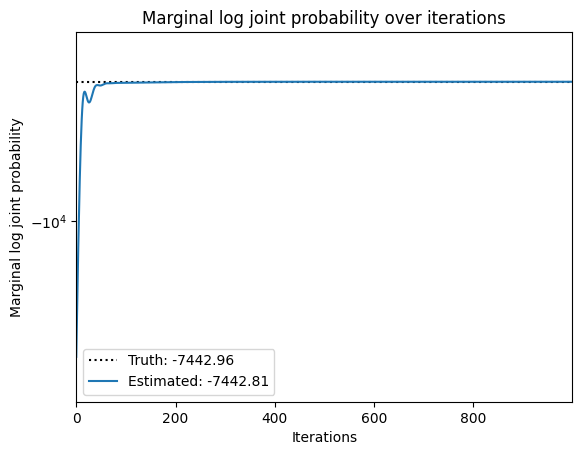

In [15]:
# Plot the marginal log likelihood learning curve
plot_mll_learning_curve(
    true_model = true_model,
    true_params = true_params,
    true_emissions = emissions,
    t_emissions = t_emissions,
    marginal_lls = sgd_loss_history,
    filter_hyperparams=ekf_hyperparams,
    plot_save_path=None # Plot here instead of saving
)

Processing array = dynamics_drift_sigma in batch mode
Processing array = dynamics_drift_rho in batch mode
Processing array = dynamics_drift_beta in batch mode
Processing non-array-like value = dynamics_drift_sigma
Processing non-array-like value = dynamics_drift_rho
Processing non-array-like value = dynamics_drift_beta
Processing array = dynamics_drift_sigma in single-sample mode
Processing array = dynamics_drift_rho in single-sample mode
Processing array = dynamics_drift_beta in single-sample mode
Processing array = dynamics_drift_sigma in single-sample mode
Processing array = dynamics_drift_rho in single-sample mode
Processing array = dynamics_drift_beta in single-sample mode


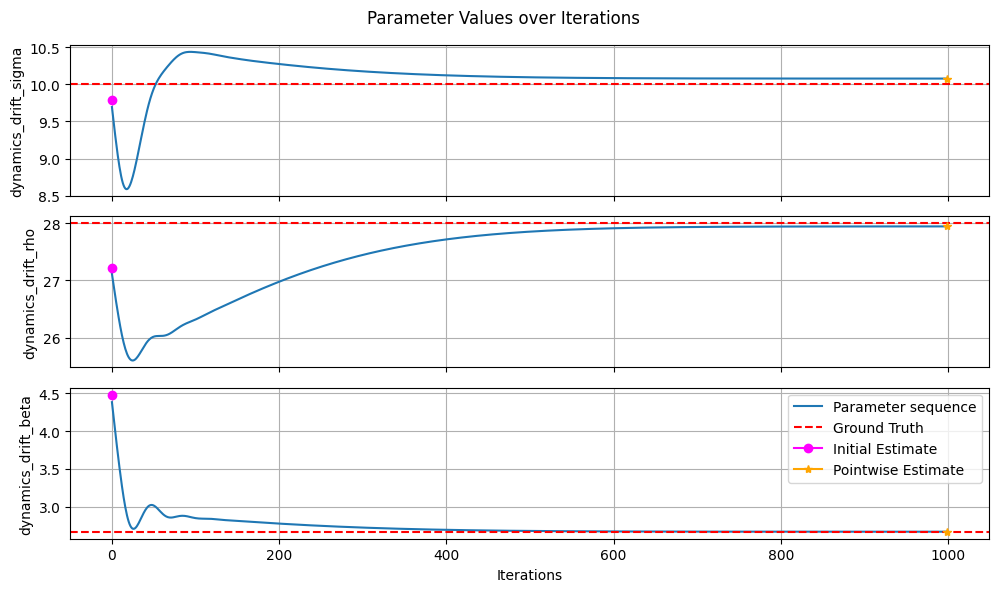

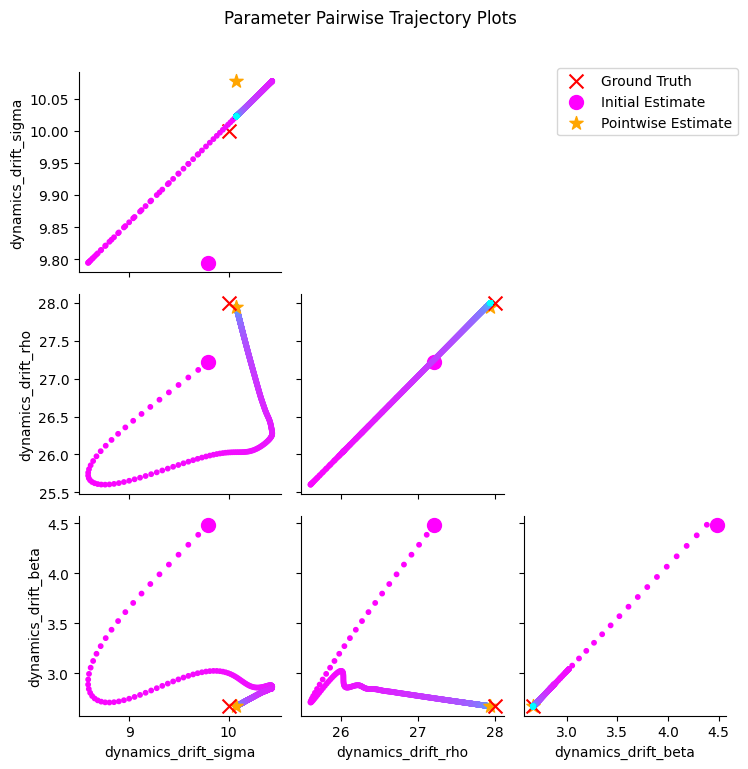

In [16]:
# Plot parameter trajectories over SGD iterations ---translating trees to dataframes
plot_param_sequences(
    param_history=learnable_params_to_1d_df(
        sgd_fitted_params_history, learnable_props, has_batch_dim=True
    ),
    true=learnable_params_to_1d_df(
        true_params, learnable_props
    ),
    init=learnable_params_to_1d_df(
        learnable_params, learnable_props
    ),
    pointwise_estimate=learnable_params_to_1d_df(
        sgd_fitted_params, learnable_props
    ),
    burn_in_frac=0.0,
    pairwise_plots=True,
    plot_save_path=None # Plot here instead of saving
)

## Filter then forecast using true and learned models

We now generate a new test trajectory from the true model, then do filtering and forecasting (using both true and learned models) to evaluate short-term forecasting performance.

In [17]:
# Define a set of time indices for filtering and forecasting
test_t_emissions = sample_t_emissions(
    start=0.0,
    stop=100.0,
    dt=0.01,
    regular=True,
    key=next(keys)
)

[make_t_emissions] Generated 10000 points from 0.0 to 100.0 with avg step ~0.0100
[make_t_emissions] Smallest time step = 0.010000


In [18]:
# Now, generate a new testing trajectory from the true model. 
test_states, test_emissions = true_model.sample(
    params=true_params,
    key=next(keys),
    num_timesteps=len(test_t_emissions),
    t_emissions=test_t_emissions,
    transition_type="path",
)

Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete non-linear Gaussian SSM path


In [19]:
# Forecasting and filtering on specific range
T0 = 45.0
T_filter_end = 50.0
T_forecast_end = 52.0

### Filtering and Forecasting with the true model 

Note that the diffusion in the true SDE model (combined with the chaotic sensitivies of the Lorenz drift) makes even high-quality forecasts diverge quickly.

In [20]:
print("Running filtering with {filter_name} with True model from T={T0} up to T={T_filter_end} and forecasting up to T={T_forecast_end}.".format(
    filter_name = ekf_info['name'] if ekf_info is not None and 'name' in ekf_info else "the specified filter",
    T0=T0, T_filter_end=T_filter_end, T_forecast_end=T_forecast_end
    )
)

# Perform filtering and forecasting
true_test_ekf_filtered, true_test_ekf_forecasted, start_idx_filter, stop_idx_filter, start_idx_forecast, stop_idx_forecast = filter_and_forecast(
    model_params=true_params,
    filter_hyperparams=ekf_hyperparams,
    t_emissions=test_t_emissions,
    emissions=test_emissions,
    T0=T0,
    T_filter_end=T_filter_end,
    T_forecast_end=T_forecast_end,
)

Running filtering with EKF (1st order) with True model from T=45.0 up to T=50.0 and forecasting up to T=52.0.


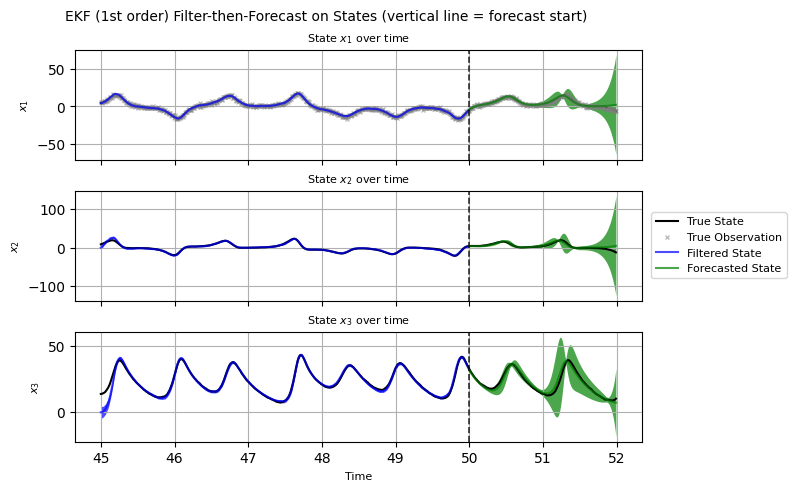

In [21]:
# Plot both filtering and forecasting results
plot_filter_then_forecast_state_results(
    data={
        'states': test_states,
        'emissions': test_emissions,
        't_emissions': test_t_emissions,
    },
    results={
        'filtered': tree_to_dict(true_test_ekf_filtered),
        'forecasted': tree_to_dict(true_test_ekf_forecasted),
        'start_idx_filter': start_idx_filter,
        'stop_idx_filter': stop_idx_filter,
        'start_idx_forecast': start_idx_forecast,
        'stop_idx_forecast': stop_idx_forecast,
    },
    plot_only_filter_forecast_window=True,
    results_file=None, # Plot here, not save
    filter_info=ekf_info,
    plot_uncertainty=True,
    plot_observations=True,
    plot_mse=False,
)

### Filtering and Forecasting with the learned model 

In [22]:
print("Running filtering with {filter_name} with Learned model from T={T0} up to T={T_filter_end} and forecasting up to T={T_forecast_end}.".format(
    filter_name = ekf_info['name'] if ekf_info is not None and 'name' in ekf_info else "the specified filter",
    T0=T0, T_filter_end=T_filter_end, T_forecast_end=T_forecast_end
    )
)

# Perform filtering and forecasting
test_ekf_filtered, test_ekf_forecasted, start_idx_filter, stop_idx_filter, start_idx_forecast, stop_idx_forecast = filter_and_forecast(
    model_params=sgd_fitted_params,
    filter_hyperparams=ekf_hyperparams,
    t_emissions=test_t_emissions,
    emissions=test_emissions,
    T0=T0,
    T_filter_end=T_filter_end,
    T_forecast_end=T_forecast_end,
)

Running filtering with EKF (1st order) with Learned model from T=45.0 up to T=50.0 and forecasting up to T=52.0.


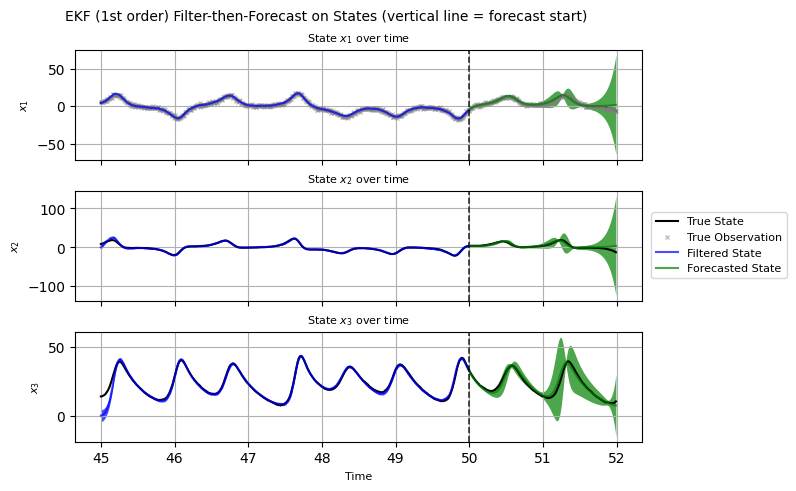

In [23]:
# Plot both filtering and forecasting results
plot_filter_then_forecast_state_results(
    data={
        'states': test_states,
        'emissions': test_emissions,
        't_emissions': test_t_emissions,
    },
    results={
        'filtered': tree_to_dict(test_ekf_filtered),
        'forecasted': tree_to_dict(test_ekf_forecasted),
        'start_idx_filter': start_idx_filter,
        'stop_idx_filter': stop_idx_filter,
        'start_idx_forecast': start_idx_forecast,
        'stop_idx_forecast': stop_idx_forecast,
    },
    plot_only_filter_forecast_window=True,
    results_file=None, # Plot here, not save
    filter_info=ekf_info,
    plot_uncertainty=True,
    plot_observations=True,
    plot_mse=False,
)

## Lorenz 63's chaotic behavior: differences in true Vs learned model forecasting

Next, we will look at the long-term statistical behavior of the learned vs true models by simulating a long trajectory from each and plotting histograms and others!!

In [24]:
# Long time emissions for long simulation: training data is too short to see true attractor
long_t_emissions = jnp.arange(
    start=0.0,
    stop=1e4,
    step=0.01
).reshape(-1, 1)

In [25]:
# Long simulation with true parameters for comparison 
true_long_states, true_long_emissions = true_model.sample(
    params=true_params,
    key=next(keys),
    num_timesteps=len(long_t_emissions),
    t_emissions=long_t_emissions,
    transition_type="path",
)

Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete non-linear Gaussian SSM path


In [26]:
# Long simulation with learned parameters
fitted_long_states, fitted_long_emissions = learnable_model.sample(
    params=sgd_fitted_params,
    key=next(keys),
    num_timesteps=len(long_t_emissions),
    t_emissions=long_t_emissions,
    transition_type="path",
)

Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete non-linear Gaussian SSM path


### Chaos dynamics plotting

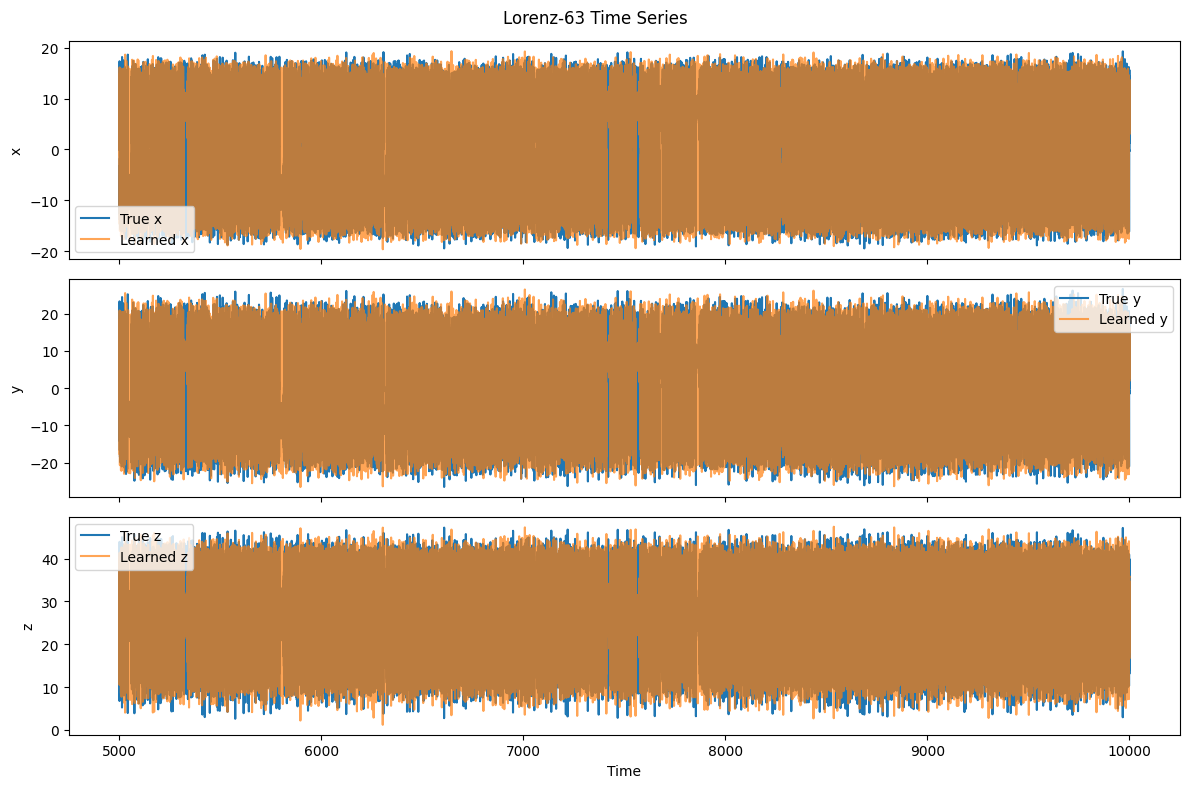

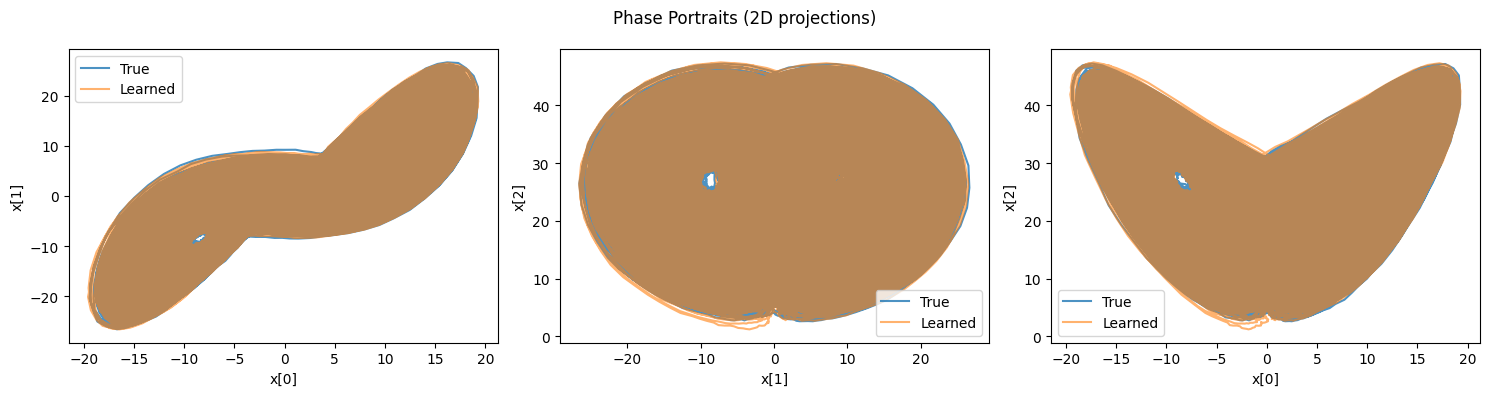

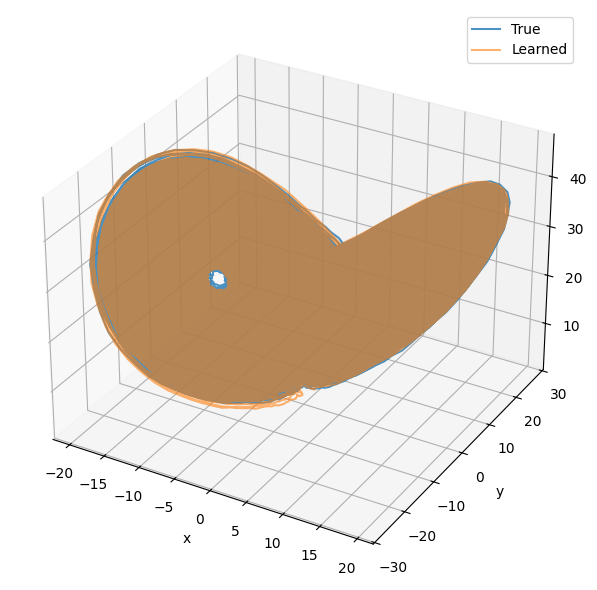

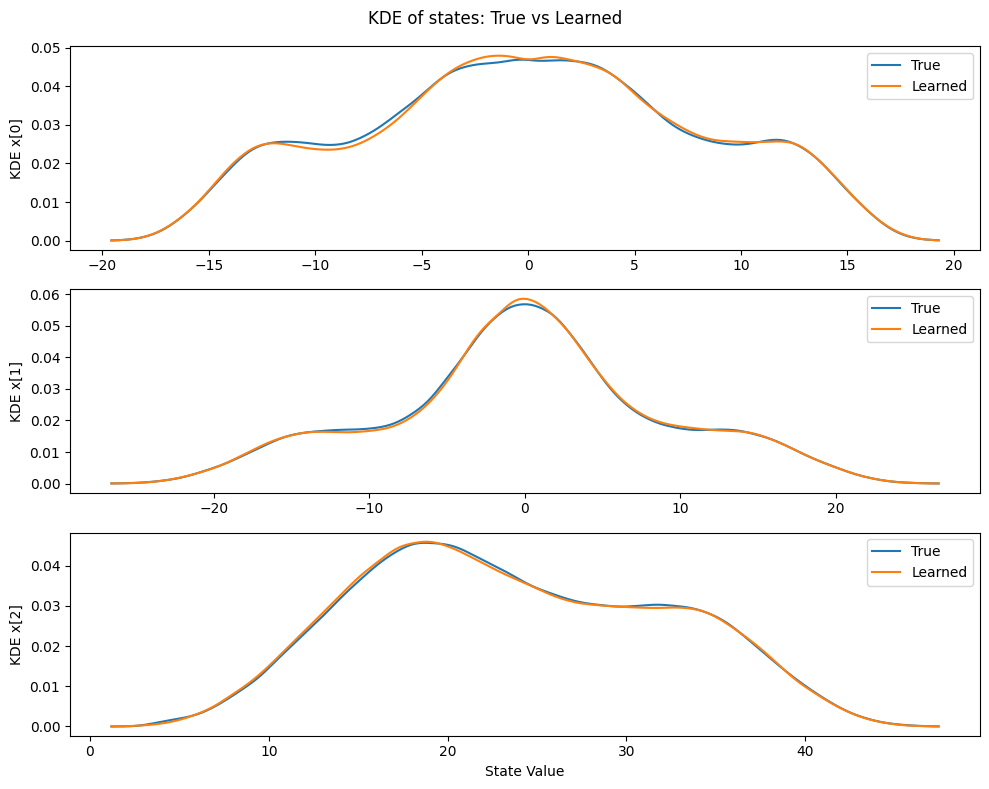

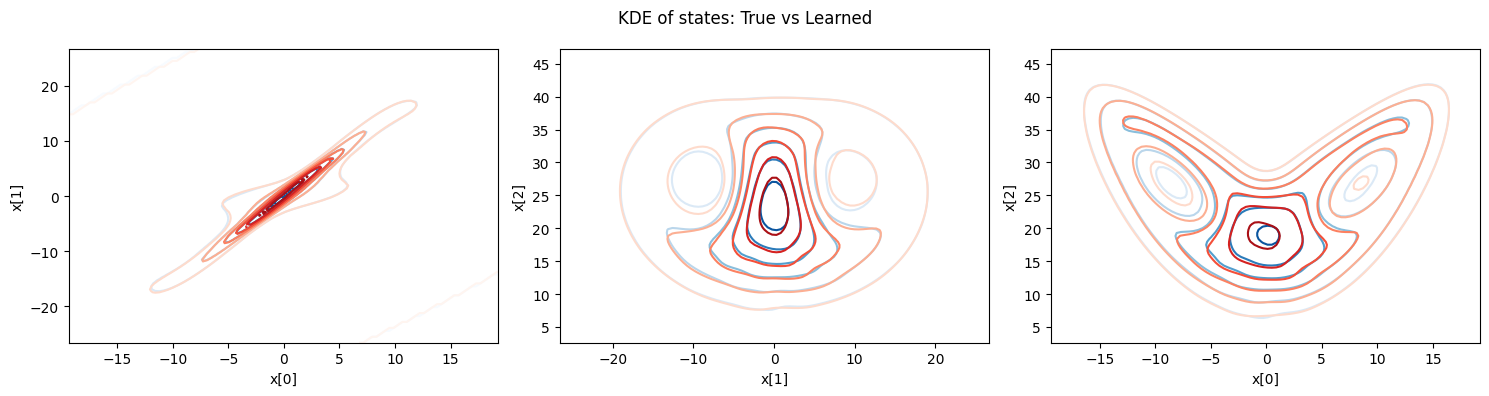

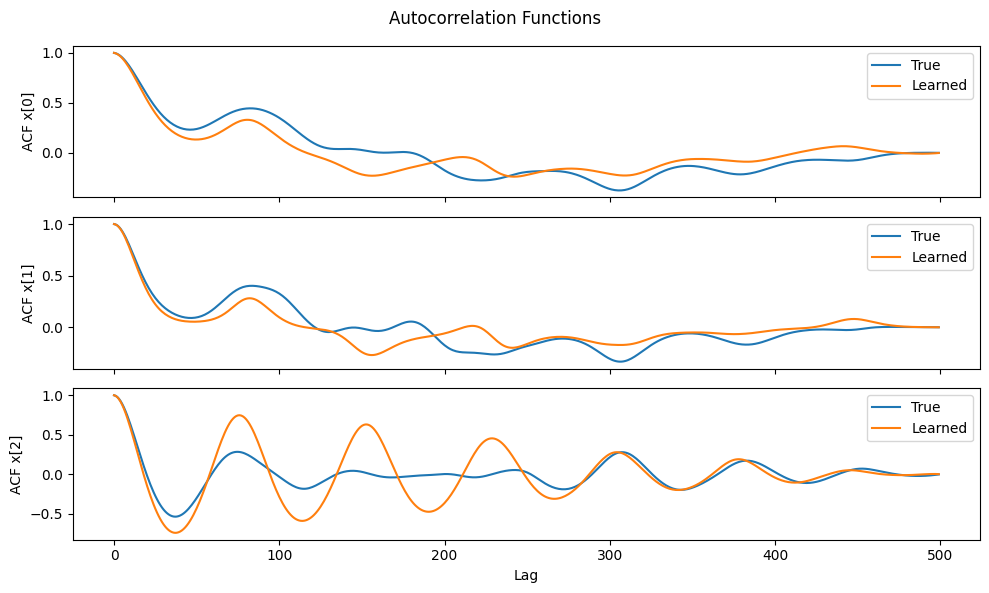

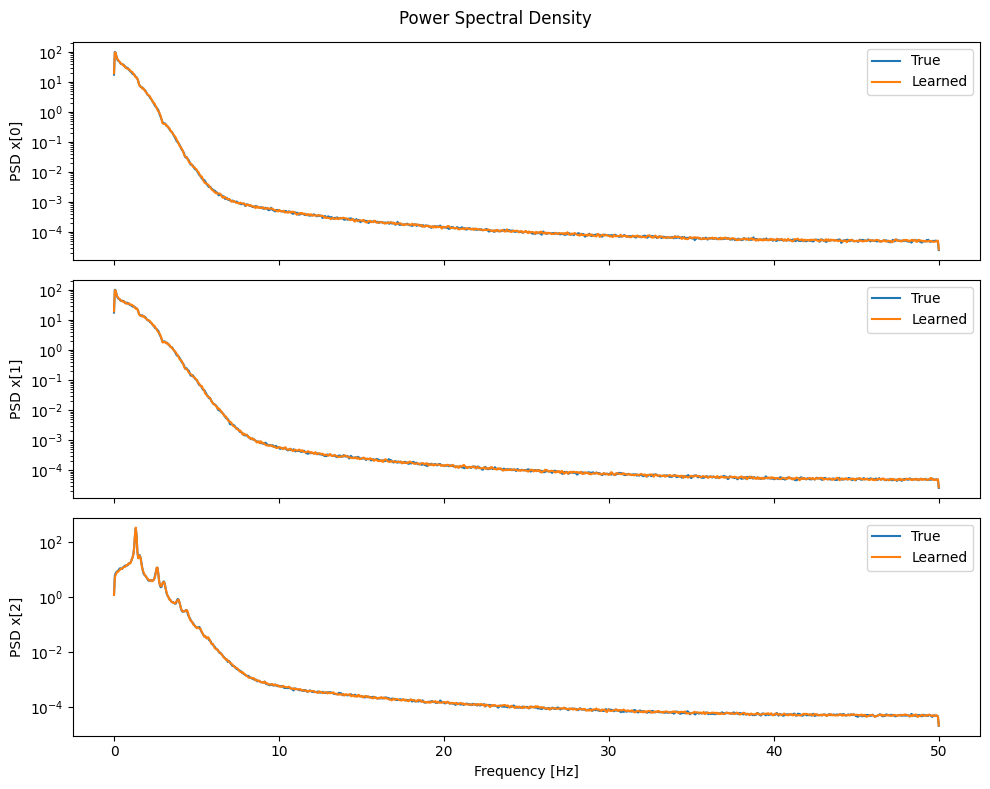

Estimated Largest Lyapunov Exponent:
  True   : 1.018
  Learned: 1.067


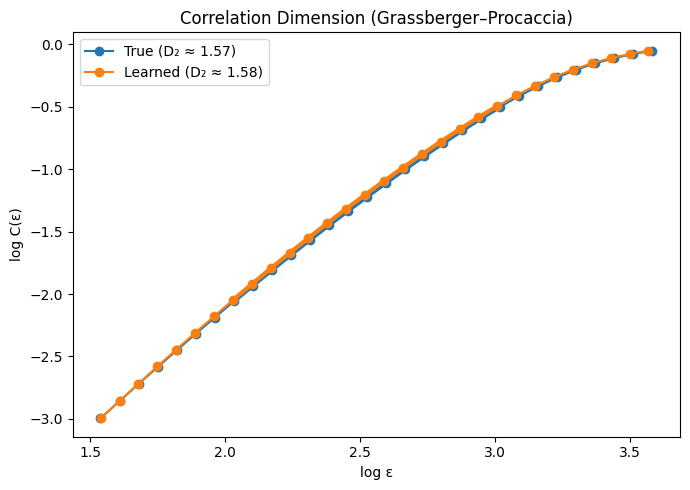

Estimated Correlation Dimension D2:
  True    : 1.575
  Learned : 1.582
Estimated Correlation Dimensions: True D2=1.575, Learned D2=1.582


In [27]:
# Let's plot some analyses: Note that we don't expect the learned 2nd and 3rd state variables to match-up at all to the true ones.
from cd_dynamax.src.utils.plotting_chaos_utils import analyze_chaotic_dynamics
analyze_chaotic_dynamics(
    true_long_states,
    fitted_long_states,
    t=long_t_emissions.squeeze(),
    drift_true=true_params.dynamics.drift.f,
    drift_learn=sgd_fitted_params.dynamics.drift.f,
    burnin_frac=0.5,
)